# 🏠 California Housing — ML Models: From Scratch vs Sklearn
### Models: Decision Tree · Random Forest · Linear Regression · Logistic Regression · KNN · Naïve Bayes

**Task:** Implement each model from scratch AND with sklearn, evaluate with metrics, compare results, and identify the best model.

---

## 0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, accuracy_score, classification_report)

# Built-in sklearn models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB

print("✔ All libraries imported successfully!")

✔ All libraries imported successfully!


## 1. Data Loading & Preprocessing

In [ ]:
# ── Load dataset ─────────────────────────────────────────────────────────────
data = fetch_california_housing(as_frame=True)
df   = data.frame

print("=" * 65)
print("  CALIFORNIA HOUSING DATASET")
print("=" * 65)
print(f"\n✔ Shape    : {df.shape}")
print(f"✔ Features : {list(data.feature_names)}")
print(f"✔ Target   : MedHouseVal (Median House Value in $100k)\n")
df.describe().round(3)

  CALIFORNIA HOUSING DATASET

✔ Shape    : (20640, 9)
✔ Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
✔ Target   : MedHouseVal (Median House Value in $100k)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [ ]:
X = df[data.feature_names].values
y = df['MedHouseVal'].values

# ── Regression split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Classification split (Low=0 / Medium=1 / High=2) ─────────────────────────
bins  = [0, 1.5, 3.0, np.inf]
y_cls = np.array(pd.cut(y, bins=bins, labels=[0,1,2]), dtype=int)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

scaler_c    = StandardScaler()
Xc_train_sc = scaler_c.fit_transform(Xc_train)
Xc_test_sc  = scaler_c.transform(Xc_test)

class_names = ['Low (≤1.5)', 'Medium (1.5–3)', 'High (>3)']
print(f"✔ Class distribution: {np.bincount(y_cls)}  (0=Low, 1=Medium, 2=High)")
print(f"✔ Train samples : {len(X_train)} | Test samples : {len(X_test)}")

✔ Class distribution: [7620 9184 3836]  (0=Low, 1=Medium, 2=High)
✔ Train samples : 16512 | Test samples : 4128


## 2. Evaluation Helper Functions

In [ ]:
def reg_metrics(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"  {label:35s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return dict(RMSE=rmse, MAE=mae, R2=r2)

def cls_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    if label:
        print(f"  {label:35s} | Accuracy={acc:.4f}")
    return dict(Accuracy=acc)

print("✔ Helper functions ready.")

✔ Helper functions ready.


## 3. Model 1 — Linear Regression
> **Scratch:** Normal Equation `w = (XᵀX)⁻¹ Xᵀy`

In [ ]:
class LinearRegressionScratch:
    """Ordinary Least Squares via Normal Equation."""
    def fit(self, X, y):
        Xb = np.c_[np.ones(X.shape[0]), X]
        self.w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y

    def predict(self, X):
        Xb = np.c_[np.ones(X.shape[0]), X]
        return Xb @ self.w

print("─" * 65)
print("  LINEAR REGRESSION RESULTS")
print("─" * 65)

# From Scratch
lr_sc = LinearRegressionScratch()
lr_sc.fit(X_train_sc, y_train)
m_lr_sc = reg_metrics(y_test, lr_sc.predict(X_test_sc), "Scratch  (Normal Equation)")

# Sklearn
lr_sk = LinearRegression()
lr_sk.fit(X_train_sc, y_train)
m_lr_sk = reg_metrics(y_test, lr_sk.predict(X_test_sc), "Sklearn  LinearRegression")

─────────────────────────────────────────────────────────────────
  LINEAR REGRESSION RESULTS
─────────────────────────────────────────────────────────────────
  Scratch  (Normal Equation)          | RMSE=0.7456  MAE=0.5332  R²=0.5758
  Sklearn  LinearRegression           | RMSE=0.7456  MAE=0.5332  R²=0.5758


## 4. Model 2 — Logistic Regression *(Classification)*
> **Scratch:** One-vs-Rest with Gradient Descent

In [ ]:
class LogisticRegressionScratch:
    """Multi-class One-vs-Rest logistic regression (gradient descent)."""
    def __init__(self, lr=0.1, n_iter=500):
        self.lr, self.n_iter = lr, n_iter

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        Xb = np.c_[np.ones(X.shape[0]), X]
        self.weights = {}
        for c in self.classes_:
            yb = (y == c).astype(float)
            w  = np.zeros(Xb.shape[1])
            for _ in range(self.n_iter):
                p  = self._sigmoid(Xb @ w)
                w -= self.lr * (Xb.T @ (p - yb)) / len(yb)
            self.weights[c] = w

    def predict(self, X):
        Xb    = np.c_[np.ones(X.shape[0]), X]
        probs = np.column_stack([self._sigmoid(Xb @ self.weights[c])
                                  for c in self.classes_])
        return self.classes_[np.argmax(probs, axis=1)]

print("─" * 65)
print("  LOGISTIC REGRESSION RESULTS  (classification)")
print("─" * 65)

logreg_sc = LogisticRegressionScratch(lr=0.1, n_iter=500)
logreg_sc.fit(Xc_train_sc, yc_train)
m_logreg_sc = cls_metrics(yc_test, logreg_sc.predict(Xc_test_sc), "Scratch  (OvR Gradient Descent)")

logreg_sk = LogisticRegression(max_iter=1000)
logreg_sk.fit(Xc_train_sc, yc_train)
logreg_sk_pred = logreg_sk.predict(Xc_test_sc)
m_logreg_sk = cls_metrics(yc_test, logreg_sk_pred, "Sklearn  LogisticRegression")

print("\nSklearn detailed report:")
print(classification_report(yc_test, logreg_sk_pred, target_names=class_names))

─────────────────────────────────────────────────────────────────
  LOGISTIC REGRESSION RESULTS  (classification)
─────────────────────────────────────────────────────────────────
  Scratch  (OvR Gradient Descent)     | Accuracy=0.7149
  Sklearn  LogisticRegression         | Accuracy=0.7345

Sklearn detailed report:
                precision    recall  f1-score   support

    Low (≤1.5)       0.80      0.77      0.78      1516
Medium (1.5–3)       0.68      0.79      0.73      1861
     High (>3)       0.76      0.53      0.62       751

      accuracy                           0.73      4128
     macro avg       0.75      0.70      0.71      4128
  weighted avg       0.74      0.73      0.73      4128



## 5. Model 3 — K-Nearest Neighbors (K=5)
> **Scratch:** Euclidean distance → mean of K neighbours

In [ ]:
class KNNScratch:
    """K-Nearest Neighbours Regressor using Euclidean distance."""
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train, self.y_train = X, y

    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            preds.append(self.y_train[np.argsort(dists)[:self.k]].mean())
        return np.array(preds)

print("─" * 65)
print("  KNN RESULTS  (k=5, regression)")
print("─" * 65)

knn_sc = KNNScratch(k=5)
knn_sc.fit(X_train_sc, y_train)
m_knn_sc = reg_metrics(y_test, knn_sc.predict(X_test_sc), "Scratch  KNN (k=5)")

knn_sk = KNeighborsRegressor(n_neighbors=5)
knn_sk.fit(X_train_sc, y_train)
m_knn_sk = reg_metrics(y_test, knn_sk.predict(X_test_sc), "Sklearn  KNeighborsRegressor")

─────────────────────────────────────────────────────────────────
  KNN RESULTS  (k=5, regression)
─────────────────────────────────────────────────────────────────
  Scratch  KNN (k=5)                  | RMSE=0.6576  MAE=0.4462  R²=0.6700
  Sklearn  KNeighborsRegressor        | RMSE=0.6576  MAE=0.4462  R²=0.6700


## 6. Model 4 — Naïve Bayes *(Classification)*
> **Scratch:** Gaussian likelihood with log-prior

In [ ]:
class GaussianNBScratch:
    """Gaussian Naïve Bayes: P(y|x) ∝ P(y) ∏ P(xᵢ|y)."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors, self.means, self.vars = {}, {}, {}
        for c in self.classes_:
            Xc = X[y == c]
            self.priors[c] = len(Xc) / len(y)
            self.means[c]  = Xc.mean(axis=0)
            self.vars[c]   = Xc.var(axis=0) + 1e-9   # Laplace smoothing

    def _log_likelihood(self, x, c):
        m, v = self.means[c], self.vars[c]
        return -0.5 * np.sum(np.log(2 * np.pi * v) + (x - m) ** 2 / v)

    def predict(self, X):
        return np.array([
            max(self.classes_,
                key=lambda c: np.log(self.priors[c]) + self._log_likelihood(x, c))
            for x in X])

print("─" * 65)
print("  NAÏVE BAYES RESULTS  (Gaussian, classification)")
print("─" * 65)

nb_sc = GaussianNBScratch()
nb_sc.fit(Xc_train_sc, yc_train)
m_nb_sc = cls_metrics(yc_test, nb_sc.predict(Xc_test_sc), "Scratch  GaussianNB")

nb_sk = GaussianNB()
nb_sk.fit(Xc_train_sc, yc_train)
nb_sk_pred = nb_sk.predict(Xc_test_sc)
m_nb_sk = cls_metrics(yc_test, nb_sk_pred, "Sklearn  GaussianNB")

print("\nSklearn detailed report:")
print(classification_report(yc_test, nb_sk_pred, target_names=class_names))

─────────────────────────────────────────────────────────────────
  NAÏVE BAYES RESULTS  (Gaussian, classification)
─────────────────────────────────────────────────────────────────
  Scratch  GaussianNB                 | Accuracy=0.5128
  Sklearn  GaussianNB                 | Accuracy=0.5128

Sklearn detailed report:
                precision    recall  f1-score   support

    Low (≤1.5)       0.89      0.07      0.13      1516
Medium (1.5–3)       0.48      0.98      0.65      1861
     High (>3)       0.80      0.26      0.39       751

      accuracy                           0.51      4128
     macro avg       0.72      0.43      0.39      4128
  weighted avg       0.69      0.51      0.41      4128



## 7. Model 5 — Decision Tree *(max_depth=5)*
> **Scratch:** CART — MSE-minimising recursive splitting

In [ ]:
class DecisionTreeScratch:
    """CART regression tree — splits on feature/threshold that minimises MSE."""
    def __init__(self, max_depth=5, min_samples_split=10, n_thresholds=20):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_thresholds = n_thresholds

    class _Node:
        def __init__(self, value=None, feat=None, thr=None, left=None, right=None):
            self.value, self.feat, self.thr = value, feat, thr
            self.left, self.right = left, right

    def _mse(self, y):
        return np.mean((y - y.mean()) ** 2) if len(y) > 0 else 0

    def _best_split(self, X, y):
        best_mse, best_f, best_t = np.inf, None, None
        n = X.shape[0]
        for f in range(X.shape[1]):
            col = X[:, f]
            # Use percentile-based candidates instead of all unique values
            candidates = np.unique(np.percentile(col, np.linspace(5, 95, self.n_thresholds)))
            for t in candidates:
                mask = col <= t
                l, r = y[mask], y[~mask]
                if len(l) == 0 or len(r) == 0:
                    continue
                mse = (len(l) * self._mse(l) + len(r) * self._mse(r)) / n
                if mse < best_mse:
                    best_mse, best_f, best_t = mse, f, t
        return best_f, best_t

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self._Node(value=y.mean())
        f, t = self._best_split(X, y)
        if f is None:
            return self._Node(value=y.mean())
        mask = X[:, f] <= t
        if mask.all() or (~mask).all():   # Guard: degenerate split
            return self._Node(value=y.mean())
        return self._Node(feat=f, thr=t,
                          left=self._build(X[mask],  y[mask],  depth+1),
                          right=self._build(X[~mask], y[~mask], depth+1))

    def fit(self, X, y):
        self.root = self._build(X, y, 0)

    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        return self._traverse(x, node.left if x[node.feat] <= node.thr else node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

print("─" * 65)
print("  DECISION TREE RESULTS  (max_depth=5, regression)")
print("─" * 65)

dt_sc = DecisionTreeScratch(max_depth=5, n_thresholds=20)
dt_sc.fit(X_train, y_train)
m_dt_sc = reg_metrics(y_test, dt_sc.predict(X_test), "Scratch  Decision Tree (d=5)")

dt_sk = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_sk.fit(X_train, y_train)
m_dt_sk = reg_metrics(y_test, dt_sk.predict(X_test), "Sklearn  DecisionTreeRegressor")


─────────────────────────────────────────────────────────────────
  DECISION TREE RESULTS  (max_depth=5, regression)
─────────────────────────────────────────────────────────────────
  Scratch  Decision Tree (d=5)        | RMSE=0.7301  MAE=0.5272  R²=0.5932
  Sklearn  DecisionTreeRegressor      | RMSE=0.7242  MAE=0.5223  R²=0.5997


## 8. Model 6 — Random Forest *(50 trees, unconstrained depth)*
> **Scratch:** Bootstrap + random feature subsets over `DecisionTreeScratch`

In [ ]:
class _RFTree:
    """Decision tree that samples max_features at EACH SPLIT NODE."""
    def __init__(self, max_depth, min_samples_split, k, n_thresholds, rng):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.k = k
        self.n_thresholds = n_thresholds
        self.rng = rng

    class _Node:
        def __init__(self, value=None, feat=None, thr=None, left=None, right=None):
            self.value, self.feat, self.thr = value, feat, thr
            self.left, self.right = left, right

    def _mse(self, y):
        return np.mean((y - y.mean()) ** 2) if len(y) > 0 else 0

    def _best_split(self, X, y):
        n, p = X.shape
        # ✔ Sample k features at THIS node (not once per tree)
        feats = self.rng.choice(p, min(self.k, p), replace=False)
        best_mse, best_f, best_t = np.inf, None, None
        for f in feats:
            col = X[:, f]
            candidates = np.unique(np.percentile(col, np.linspace(5, 95, self.n_thresholds)))
            for t in candidates:
                mask = col <= t
                l, r = y[mask], y[~mask]
                if len(l) == 0 or len(r) == 0:
                    continue
                mse = (len(l) * self._mse(l) + len(r) * self._mse(r)) / n
                if mse < best_mse:
                    best_mse, best_f, best_t = mse, f, t
        return best_f, best_t

    def _build(self, X, y, depth):
        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_samples_split:
            return self._Node(value=y.mean())
        f, t = self._best_split(X, y)
        if f is None:
            return self._Node(value=y.mean())
        mask = X[:, f] <= t
        if mask.all() or (~mask).all():
            return self._Node(value=y.mean())
        return self._Node(feat=f, thr=t,
                          left=self._build(X[mask],  y[mask],  depth+1),
                          right=self._build(X[~mask], y[~mask], depth+1))

    def fit(self, X, y):
        self.root = self._build(X, y, 0)

    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        return self._traverse(x, node.left if x[node.feat] <= node.thr else node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])


class RandomForestScratch:
    """Ensemble of _RFTree with bootstrap + per-split feature sampling."""
    def __init__(self, n_trees=50, max_depth=None, min_samples_split=10,
                 max_features='sqrt', n_thresholds=20, random_state=42):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.rng = np.random.RandomState(random_state)
        self.trees = []

    def fit(self, X, y):
        n, p = X.shape
        k = max(1, int(np.sqrt(p))) if self.max_features == 'sqrt' else p
        for _ in range(self.n_trees):
            idx = self.rng.choice(n, n, replace=True)          # Bootstrap
            tree = _RFTree(self.max_depth, self.min_samples_split,
                           k, self.n_thresholds, self.rng)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)

    def predict(self, X):
        return np.column_stack([tree.predict(X) for tree in self.trees]).mean(axis=1)


print("─" * 65)
print("  RANDOM FOREST RESULTS  (50 trees, unconstrained depth, regression)")
print("─" * 65)
print("  [Training FIXED scratch RF — per-split feature sampling]")

rf_sc = RandomForestScratch(n_trees=50, max_depth=None)
rf_sc.fit(X_train, y_train)
rf_sc_pred = rf_sc.predict(X_test)
m_rf_sc = reg_metrics(y_test, rf_sc_pred, "Scratch  Random Forest (50 trees)")

rf_sk = RandomForestRegressor(n_estimators=50, random_state=42)
rf_sk.fit(X_train, y_train)
rf_sk_pred = rf_sk.predict(X_test)
m_rf_sk = reg_metrics(y_test, rf_sk_pred, "Sklearn  RandomForestRegressor")


─────────────────────────────────────────────────────────────────
  RANDOM FOREST RESULTS  (50 trees, unconstrained depth, regression)
─────────────────────────────────────────────────────────────────
  [Training FIXED scratch RF — per-split feature sampling]
  Scratch  Random Forest (50 trees)   | RMSE=0.5055  MAE=0.3398  R²=0.8050
  Sklearn  RandomForestRegressor      | RMSE=0.5072  MAE=0.3303  R²=0.8037


## 9. Comparison Tables

In [ ]:
# ── Regression table ─────────────────────────────────────────────────────────
reg_rows = [
    ("Linear Regression",   m_lr_sc,      m_lr_sk),
    ("KNN (k=5)",           m_knn_sc,     m_knn_sk),
    ("Decision Tree (d=5)", m_dt_sc,      m_dt_sk),
    ("Random Forest (50)",  m_rf_sc,  m_rf_sk),
]

print("=" * 68)
print("  REGRESSION MODELS — SCRATCH vs SKLEARN")
print("=" * 68)
print(f"{'Model':<26} {'Impl':>6} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("─" * 60)
for name, sc, sk in reg_rows:
    print(f"{name:<26} {'Scratch':>6} {sc['RMSE']:>8.4f} {sc['MAE']:>8.4f} {sc['R2']:>8.4f}")
    print(f"{'':26} {'Sklearn':>6} {sk['RMSE']:>8.4f} {sk['MAE']:>8.4f} {sk['R2']:>8.4f}")
    print()

# ── Classification table ──────────────────────────────────────────────────────
cls_rows = [
    ("Logistic Regression", m_logreg_sc, m_logreg_sk),
    ("Naïve Bayes",         m_nb_sc,     m_nb_sk),
]

print("=" * 50)
print("  CLASSIFICATION MODELS — SCRATCH vs SKLEARN")
print("=" * 50)
print(f"{'Model':<26} {'Impl':>6} {'Accuracy':>10}")
print("─" * 44)
for name, sc, sk in cls_rows:
    print(f"{name:<26} {'Scratch':>6} {sc['Accuracy']:>10.4f}")
    print(f"{'':26} {'Sklearn':>6} {sk['Accuracy']:>10.4f}")
    print()

  REGRESSION MODELS — SCRATCH vs SKLEARN
Model                        Impl     RMSE      MAE       R²
────────────────────────────────────────────────────────────
Linear Regression          Scratch   0.7456   0.5332   0.5758
                           Sklearn   0.7456   0.5332   0.5758

KNN (k=5)                  Scratch   0.6576   0.4462   0.6700
                           Sklearn   0.6576   0.4462   0.6700

Decision Tree (d=5)        Scratch   0.7301   0.5272   0.5932
                           Sklearn   0.7242   0.5223   0.5997

Random Forest (50)         Scratch   0.5055   0.3398   0.8050
                           Sklearn   0.5072   0.3303   0.8037

  CLASSIFICATION MODELS — SCRATCH vs SKLEARN
Model                        Impl   Accuracy
────────────────────────────────────────────
Logistic Regression        Scratch     0.7149
                           Sklearn     0.7345

Naïve Bayes                Scratch     0.5128
                           Sklearn     0.5128



## 10. Visualisations

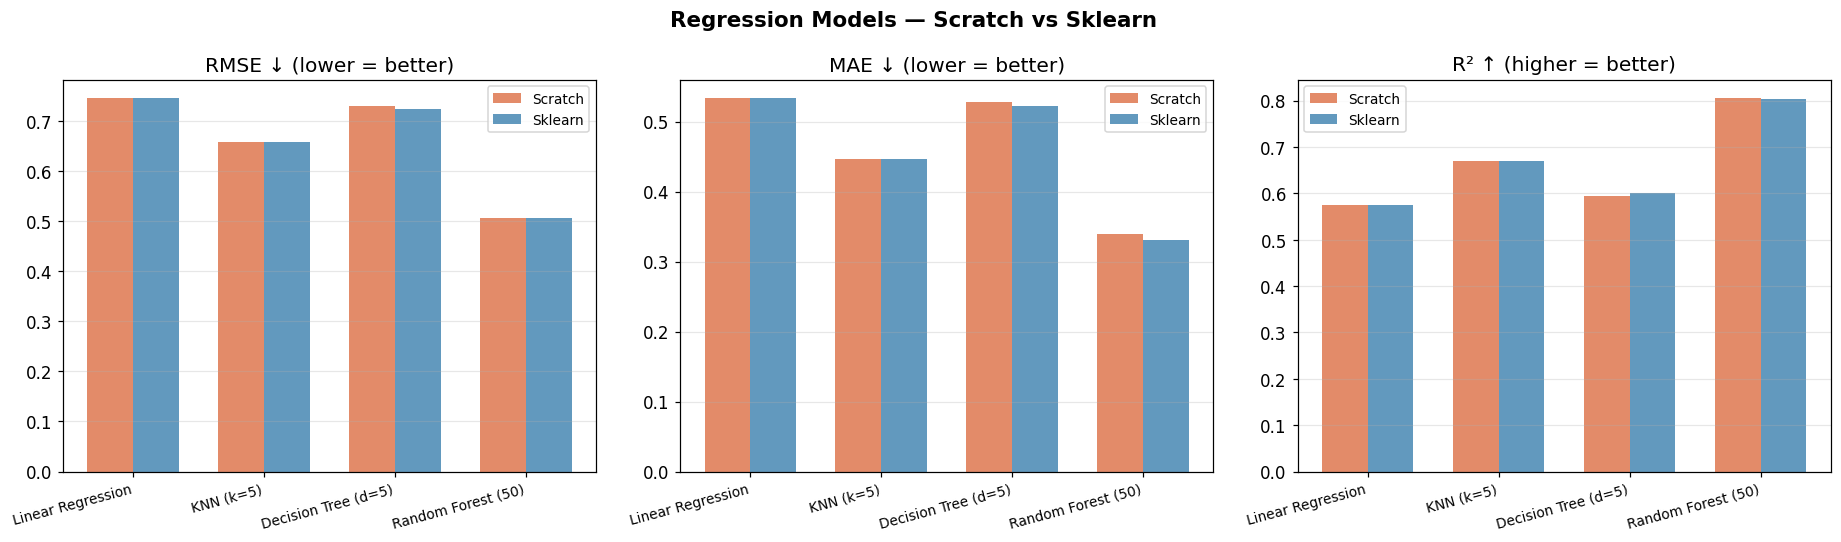

In [ ]:
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
C = {'scratch': '#E07B54', 'sklearn': '#4C8BB5'}

# ── Fig 1: Regression bar comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Regression Models — Scratch vs Sklearn", fontsize=14, fontweight='bold')

model_names = [r[0] for r in reg_rows]
x, w = np.arange(len(model_names)), 0.35

for ax, met, title in zip(axes,
        ['RMSE', 'MAE', 'R2'],
        ['RMSE ↓ (lower = better)', 'MAE ↓ (lower = better)', 'R² ↑ (higher = better)']):
    ax.bar(x - w/2, [r[1][met] for r in reg_rows], w, label='Scratch', color=C['scratch'], alpha=0.88)
    ax.bar(x + w/2, [r[2][met] for r in reg_rows], w, label='Sklearn', color=C['sklearn'], alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

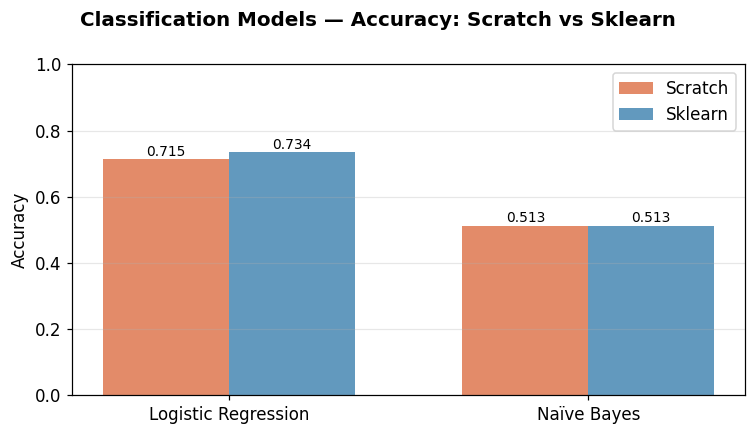

In [ ]:
# ── Fig 2: Classification accuracy ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle("Classification Models — Accuracy: Scratch vs Sklearn", fontsize=13, fontweight='bold')

xc = np.arange(len(cls_rows))
ax2.bar(xc - w/2, [r[1]['Accuracy'] for r in cls_rows], w, label='Scratch', color=C['scratch'], alpha=0.88)
ax2.bar(xc + w/2, [r[2]['Accuracy'] for r in cls_rows], w, label='Sklearn', color=C['sklearn'], alpha=0.88)
ax2.set_xticks(xc); ax2.set_xticklabels([r[0] for r in cls_rows])
ax2.set_ylim(0, 1); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

for i, row in enumerate(cls_rows):
    a, b = row[1]['Accuracy'], row[2]['Accuracy']
    ax2.text(xc[i]-w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=9)
    ax2.text(xc[i]+w/2, b+0.01, f'{b:.3f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

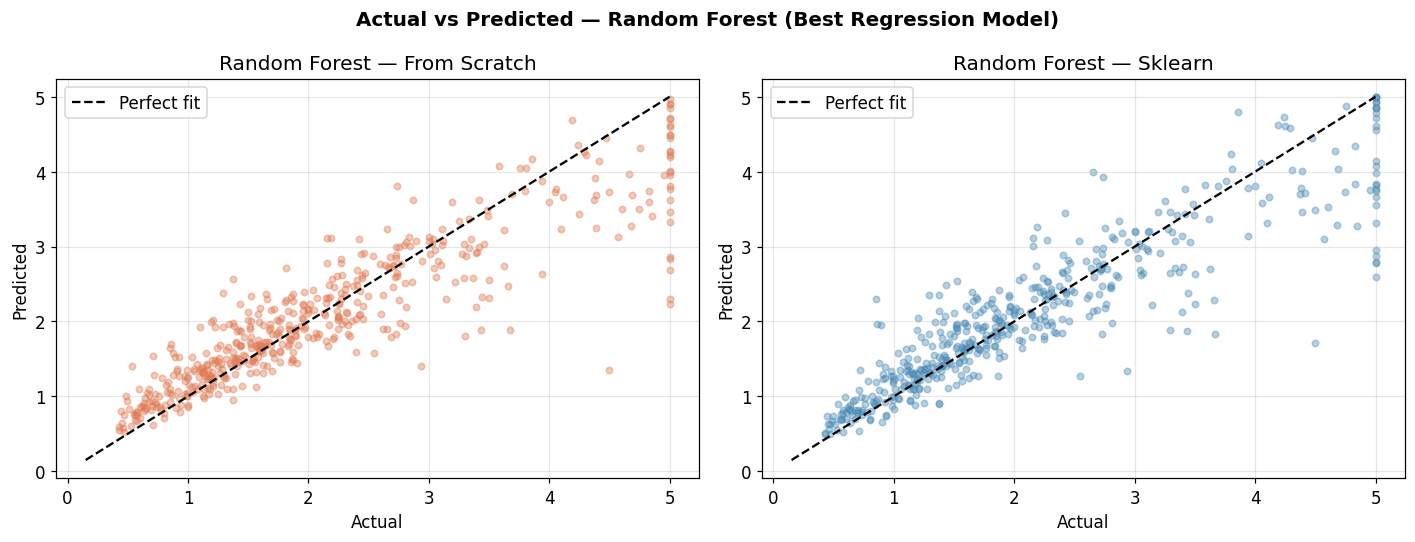

In [ ]:
# ── Fig 3: Actual vs Predicted (Random Forest) ───────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Actual vs Predicted — Random Forest (Best Regression Model)",
              fontsize=13, fontweight='bold')

sample = np.random.choice(len(y_test), 500, replace=False)
lim    = [y_test.min(), y_test.max()]

for ax, pred, label, col in zip(axes3,
        [rf_sc_pred[sample], rf_sk_pred[sample]],
        ['From Scratch', 'Sklearn'],
        [C['scratch'], C['sklearn']]):
    ax.scatter(y_test[sample], pred, alpha=0.4, s=18, color=col)
    ax.plot(lim, lim, 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'Random Forest — {label}')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

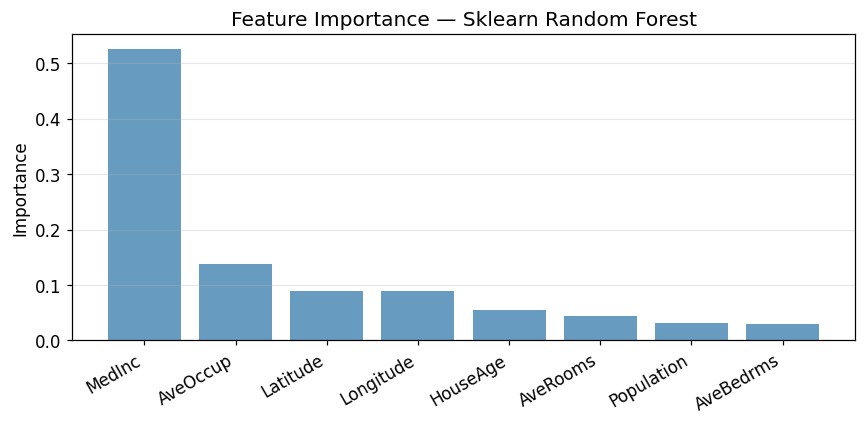

In [ ]:
# ── Fig 4: Feature importance (Sklearn RF) ───────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(8, 4))
importances = rf_sk.feature_importances_
feat_names  = data.feature_names
sort_idx    = np.argsort(importances)[::-1]

ax4.bar(range(len(feat_names)), importances[sort_idx], color=C['sklearn'], alpha=0.85)
ax4.set_xticks(range(len(feat_names)))
ax4.set_xticklabels([feat_names[i] for i in sort_idx], rotation=30, ha='right')
ax4.set_ylabel('Importance')
ax4.set_title('Feature Importance — Sklearn Random Forest')
ax4.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Best Model Analysis & Conclusion

In [ ]:
all_reg = {
    "Linear Regression"  : m_lr_sk['R2'],
    "KNN (k=5)"          : m_knn_sk['R2'],
    "Decision Tree (d=5)": m_dt_sk['R2'],
    "Random Forest (50)" : m_rf_sk['R2'],
}
all_cls = {
    "Logistic Regression": m_logreg_sk['Accuracy'],
    "Naïve Bayes"        : m_nb_sk['Accuracy'],
}

best_reg = max(all_reg, key=all_reg.get)
best_cls = max(all_cls, key=all_cls.get)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    🏆  BEST MODELS                          ║
╠══════════════════════════════════════════════════════════════╣
║  Regression    : {best_reg:<26}  R² = {all_reg[best_reg]:.4f}     ║
║  Classification: {best_cls:<26} Acc = {all_cls[best_cls]:.4f}     ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                    🏆  BEST MODELS                          ║
╠══════════════════════════════════════════════════════════════╣
║  Regression    : Random Forest (50)          R² = 0.8037     ║
║  Classification: Logistic Regression        Acc = 0.7345     ║
╚══════════════════════════════════════════════════════════════╝

